# Gemini-alapú IMDb sentiment analízis – 1000-es véletlen minta

## Gemini 2.5 Flash és Gemini 2.5 Flash-Lite összehasonlítása

## Tartalomjegyzék

Ez a notebook az eredeti, két ChatGPT-modellre épülő megoldás **Gemini API-ra átírt változata**.
A cél itt már nemcsak a sentiment címkék előállítása, hanem **két Gemini-modell összehasonlítása ugyanazon az 1000 elemű IMDb mintán**.

Az összehasonlított modellek:
- `gemini-2.5-flash`
- `gemini-2.5-flash-lite`

A további cellákban ugyanaz a workflow marad meg, mint a feltöltött notebookban,
de a vonatkozó pontokon a kód **OpenAI helyett Gemini API-val** működik.


In [ ]:
# ============================================================
# 2. Könyvtárak telepítése
# ============================================================
# Ez a cella telepíti a szükséges Python-csomagokat.
# Colab runtime újraindítás vagy környezetváltás után ezt újra futtatni kell.

!pip -q install -U google-genai pandas scikit-learn matplotlib seaborn


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.3/52.3 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 7.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 733.5/733.5 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 61.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 64.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 56.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.1 which is incompatible.
db-dtypes 1.5.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.1 which is in

In [ ]:
# ============================================================
# 3. Könyvtárak importálása
# ============================================================

import os
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from google.colab import drive, userdata
from google import genai
from google.genai import types


In [ ]:
# ============================================================
# 4. Google Drive csatlakoztatása
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 5. Gemini API-kulcs biztonságos beolvasása Colab Secretsből

Ez a notebook **nem** írja bele az API-kulcsot a kódba. Ehelyett a kulcsot a Colab Secretsből olvassa be.


In [ ]:
# ============================================================
# 5. Gemini API-kulcs beolvasása Colab Secretsből
# ============================================================

GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")

if not GEMINI_API_KEY:
    raise ValueError(
        "Nem található a GEMINI_API_KEY a Colab Secretsben. "
        "Nyisd meg a bal oldali Secrets panelt, és add hozzá."
    )

print("A Gemini API-kulcs sikeresen beolvasva a Colab Secretsből.")


A Gemini API-kulcs sikeresen beolvasva a Colab Secretsből.


## 6. IMDb adathalmaz betöltése

Ez a cella a Hugging Face-ről tölti be a korábban használt IMDb adatbázist.
Ha más útvonalat szeretnénk használni, itt kell módosítani.

In [ ]:
# ============================================================
# 6. IMDb adathalmaz betöltése
# ============================================================

CSV_PATH = "hf://datasets/Q-b1t/IMDB-Dataset-of-50K-Movie-Reviews-Backup/archive.zip"

df = pd.read_csv(CSV_PATH, compression="zip")

print("A teljes adathalmaz mérete:", df.shape)
print("\nOszlopok:", df.columns.tolist())
print("\nCímkék eloszlása:")
print(df["sentiment"].value_counts())

display(pd.concat([df.head(3), df.tail(3)]))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


A teljes adathalmaz mérete: (50000, 2)

Oszlopok: ['review', 'sentiment']

Címkék eloszlása:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative
49999,No one expects the Star Trek movies to be high...,negative


## 7. 1000 elemű véletlen minta kiválasztása

Itt választjuk ki a pilot elemzéshez használt véletlen mintát.
A `random_state` biztosítja a reprodukálhatóságot.

In [ ]:
# ============================================================
# 7. 1000 elemű véletlen minta kiválasztása
# ============================================================

SAMPLE_SIZE = 1000
RANDOM_STATE = 42

sample_df = df.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE).copy()
sample_df.reset_index(drop=True, inplace=True)

print("A kiválasztott minta mérete:", sample_df.shape)
print("\nA minta címkeeloszlása:")
print(sample_df["sentiment"].value_counts())
print("\nArányok:")
print(sample_df["sentiment"].value_counts(normalize=True))

display(sample_df.head())

A kiválasztott minta mérete: (1000, 2)

A minta címkeeloszlása:
sentiment
negative    524
positive    476
Name: count, dtype: int64

Arányok:
sentiment
negative    0.524
positive    0.476
Name: proportion, dtype: float64


,review,sentiment
0,I really liked this Summerslam due to the look...,positive
1,Not many television shows appeal to quite as m...,positive
2,The film quickly gets to a major chase scene w...,negative
3,Jane Austen would definitely approve of this o...,positive
4,Expectations were somewhat high for me when I ...,negative


## 8. A minta mentése Google Drive-ba

Ez a cella létrehozza a célmappát a Drive-ban, majd elmenti az 1000-es mintát.
Így később ugyanazzal a mintával tudsz dolgozni BERT-tel, Gemini-vel vagy más modellekkel is.


In [ ]:
# ============================================================
# 8. A minta mentése Google Drive-ba
# ============================================================

OUTPUT_DIR = "/content/drive/MyDrive/Privat/Study/PE/SZD/IMDb_Gemini_Flash_vs_FlashLite/DATA"
os.makedirs(OUTPUT_DIR, exist_ok=True)

SAMPLE_CSV_PATH = os.path.join(OUTPUT_DIR, "imdb_random_1000_sample.csv")
sample_df.to_csv(SAMPLE_CSV_PATH, index=False, encoding="utf-8")

print(f"A véletlen minta elmentve ide: {SAMPLE_CSV_PATH}")


A véletlen minta elmentve ide: /content/drive/MyDrive/Privat/Study/PE/SZD/IMDb_Gemini_Flash_vs_FlashLite/DATA/imdb_random_1000_sample.csv


In [ ]:
import os
os.listdir("/content/drive/MyDrive/Privat/Study/PE/SZD/IMDb_Gemini_Flash_vs_FlashLite/DATA")



['imdb_random_1000_sample.csv másolata', 'imdb_random_1000_sample.csv']

In [ ]:
!ls -lah "/content/drive/MyDrive/Privat/Study/PE/SZD/IMDb_Gemini_Flash_vs_FlashLite/DATA"



total 1.3M
-rw------- 1 root root 1.3M Mar 14 12:23 imdb_random_1000_sample.csv


In [ ]:
# ============================================================
# Az 1000-es IMDb minta beolvasása a Google Drive-ról
# és az első 5 sor kiírása
# ============================================================

import pandas as pd

file_path = "/content/drive/MyDrive/Privat/Study/PE/SZD/IMDb_Gemini_Flash_vs_FlashLite/DATA/imdb_random_1000_sample.csv"

sample_df = pd.read_csv(file_path)

print("Adatkeret mérete:", sample_df.shape)
print("\nAz első 5 sor:\n")

sample_df.head()



Adatkeret mérete: (1000, 2)

Az első 5 sor:



,review,sentiment
0,I really liked this Summerslam due to the look...,positive
1,Not many television shows appeal to quite as m...,positive
2,The film quickly gets to a major chase scene w...,negative
3,Jane Austen would definitely approve of this o...,positive
4,Expectations were somewhat high for me when I ...,negative


## 9. Gemini kliens inicializálása

Ez a cella létrehozza a Gemini kliensobjektumot.
A későbbi API-hívások ezen keresztül történnek.

Ebben a változatban **két modellnévvel dolgozunk**, mert a cél a
**Gemini 2.5 Flash** és a **Gemini 2.5 Flash-Lite** modell összehasonlítása
ugyanazon az IMDb-mintán.

A továbbiakban minden predikció, metrika és hibaelemzés modellenként külön kerül mentésre és kiértékelésre.



In [ ]:
# ============================================================
# 9. Gemini kliens inicializálása
# ============================================================

client = genai.Client(api_key=GEMINI_API_KEY)

MODEL_NAMES = [
    "gemini-2.5-flash",
    "gemini-2.5-flash-lite"
]

print("Gemini kliens inicializálva.")
print("Összehasonlított modellek:", MODEL_NAMES)



Gemini kliens inicializálva.
Összehasonlított modellek: ['gemini-2.5-flash', 'gemini-2.5-flash-lite']


## 10. Gemini-alapú sentiment osztályozó függvény

A cél az, hogy a modell **csak** `positive` vagy `negative` címkét adjon vissza.
A függvény tartalmaz hibakezelést és újrapróbálkozási logikát is.

Az eredeti, működő Flash-Lite notebook logikáját megtartva itt is ugyanazzal a
függvénnyel dolgozunk, de a `model_name` paraméter révén most már **mindkét modellt**
le tudjuk futtatni ugyanazon a review-n.



In [ ]:
# ============================================================
# 10. Gemini-alapú sentiment osztályozó függvény
# ============================================================

import time

def classify_sentiment_with_gemini(
    review_text,
    model_name,
    sleep_seconds=1.0,
    max_retries=3,
    verbose=False
):
    """
    Egyetlen IMDb review Gemini-alapú sentiment osztályozása.

    Paraméterek:
    review_text : str
        A filmkritika szövege
    model_name : str
        A használt Gemini modell neve
    sleep_seconds : float
        Két API-hívás közötti várakozás
    max_retries : int
        Hiba esetén újrapróbálkozások száma
    verbose : bool
        Debug üzenetek kiírása

    Visszatérési érték:
    "positive", "negative" vagy None
    """

    prompt = f'''You are an IMDb sentiment classifier.

Task:
Classify the following movie review into exactly one of these two labels:
positive
negative

Important:
- Return only one single word.
- Do not explain your answer.
- Do not use JSON.
- Do not add punctuation.

Review:
\"\"\"{review_text}\"\"\"
'''

    def extract_text_from_response(response):
        output_text = ""

        # 1. Elsődleges kiolvasás
        try:
            if hasattr(response, "text") and response.text:
                output_text = response.text.strip()
        except Exception:
            pass

        # 2. Fallback: candidates -> content -> parts
        if not output_text:
            try:
                if hasattr(response, "candidates") and response.candidates:
                    collected = []
                    parts = response.candidates[0].content.parts

                    for part in parts:
                        if hasattr(part, "text") and part.text:
                            collected.append(part.text)

                    output_text = " ".join(collected).strip()
            except Exception:
                pass

        return output_text

    for attempt in range(1, max_retries + 1):
        try:
            response = client.models.generate_content(
                model=model_name,
                contents=prompt,
                config=types.GenerateContentConfig(
                    temperature=0,
                    max_output_tokens=5
                )
            )

            output_text = extract_text_from_response(response)
            normalized = output_text.lower().replace(".", "").replace(",", "").strip()

            if verbose:
                print(f"[DEBUG] Modell: {model_name}")
                print(f"[DEBUG] próbálkozás: {attempt}")
                print(f"[DEBUG] nyers válasz: {repr(output_text)}")
                print(f"[DEBUG] normalizált válasz: {repr(normalized)}")

            if normalized == "positive":
                label = "positive"
            elif normalized == "negative":
                label = "negative"
            elif "positive" in normalized and "negative" not in normalized:
                label = "positive"
            elif "negative" in normalized and "positive" not in normalized:
                label = "negative"
            else:
                label = None

            time.sleep(sleep_seconds)
            return label

        except Exception as e:
            err_text = str(e)
            print(f"Hiba történt API-hívás során ({model_name}, próbálkozás {attempt}): {e}")

            transient_error = (
                "429" in err_text
                or "RESOURCE_EXHAUSTED" in err_text
                or "503" in err_text
                or "UNAVAILABLE" in err_text
            )

            if transient_error and attempt < max_retries:
                wait_time = 20 * attempt
                print(f"Várakozás {wait_time} másodpercig, majd újrapróbálás...")
                time.sleep(wait_time)
                continue

            return None

## 11. A minta elemzése Gemini-vel

Ez a cellacsoport végigmegy az 1000 elemű mintán, és minden review-ra lekéri
a Gemini-alapú címkét.

Az egymodelles, működő Flash-Lite notebook logikája itt is megmarad, de most
ugyanezt a folyamatot **külön lefuttatjuk a Gemini 2.5 Flash és a Gemini 2.5 Flash-Lite**
modellekre is. Ennek eredményeként a DataFrame-ben modellenként külön predikciós oszlop jön létre.



In [ ]:
# ============================================================
# 11. Gyors teszt: Gemini sentiment elemzés 5 review-n két modellel
# ============================================================

test_df = sample_df.head(5).copy()

for model_name in MODEL_NAMES:
    pred_col = f"gemini_prediction_{model_name.replace('.', '_').replace('-', '_')}"

    print("=" * 70)
    print(f"Gyors teszt fut a modellen: {model_name}")
    print("=" * 70)

    test_predictions = []

    for i, review_text in enumerate(test_df["review"], start=1):
        print(f"{i}. review feldolgozása...")

        pred = classify_sentiment_with_gemini(
            review_text=review_text,
            model_name=model_name,
            sleep_seconds=1.0,
            max_retries=3,
            verbose=True
        )

        test_predictions.append(pred)

    test_df[pred_col] = test_predictions

display(test_df)



Gyors teszt fut a modellen: gemini-2.5-flash
1. review feldolgozása...
[DEBUG] Modell: gemini-2.5-flash
[DEBUG] próbálkozás: 1
[DEBUG] nyers válasz: 'positive'
[DEBUG] normalizált válasz: 'positive'
2. review feldolgozása...
[DEBUG] Modell: gemini-2.5-flash
[DEBUG] próbálkozás: 1
[DEBUG] nyers válasz: ''
[DEBUG] normalizált válasz: ''
3. review feldolgozása...
[DEBUG] Modell: gemini-2.5-flash
[DEBUG] próbálkozás: 1
[DEBUG] nyers válasz: 'negative'
[DEBUG] normalizált válasz: 'negative'
4. review feldolgozása...
[DEBUG] Modell: gemini-2.5-flash
[DEBUG] próbálkozás: 1
[DEBUG] nyers válasz: 'positive'
[DEBUG] normalizált válasz: 'positive'
5. review feldolgozása...
[DEBUG] Modell: gemini-2.5-flash
[DEBUG] próbálkozás: 1
[DEBUG] nyers válasz: ''
[DEBUG] normalizált válasz: ''
Gyors teszt fut a modellen: gemini-2.5-flash-lite
1. review feldolgozása...
[DEBUG] Modell: gemini-2.5-flash-lite
[DEBUG] próbálkozás: 1
[DEBUG] nyers válasz: 'positive'
[DEBUG] normalizált válasz: 'positive'
2. revie

,review,sentiment,gemini_prediction_gemini_2_5_flash,gemini_prediction_gemini_2_5_flash_lite
0,I really liked this Summerslam due to the look...,positive,positive,positive
1,Not many television shows appeal to quite as m...,positive,NaN,positive
2,The film quickly gets to a major chase scene w...,negative,negative,negative
3,Jane Austen would definitely approve of this o...,positive,positive,positive
4,Expectations were somewhat high for me when I ...,negative,NaN,negative


In [ ]:
# ============================================================
# 12. Teljes IMDb minta feldolgozása Gemini modellekkel
# ============================================================

# A teljes dataset feldolgozása mindkét modellen
# A predikciók külön oszlopba kerülnek.

for model_name in MODEL_NAMES:

    pred_col = f"gemini_prediction_{model_name.replace('.', '_').replace('-', '_')}"

    print("=" * 70)
    print(f"Teljes futás indul a modellen: {model_name}")
    print("=" * 70)

    predictions = []

    for i, review_text in enumerate(sample_df["review"], start=1):

        if i % 20 == 0:
            print(f"{i}. review feldolgozva...")

        pred = classify_sentiment_with_gemini(
            review_text=review_text,
            model_name=model_name,
            sleep_seconds=1.0,
            max_retries=3,
            verbose=False
        )

        predictions.append(pred)

    sample_df[pred_col] = predictions

print("Feldolgozás befejezve.")
display(sample_df.head())

Teljes futás indul a modellen: gemini-2.5-flash
20. review feldolgozva...
40. review feldolgozva...
60. review feldolgozva...
80. review feldolgozva...
100. review feldolgozva...
120. review feldolgozva...
140. review feldolgozva...
160. review feldolgozva...
180. review feldolgozva...
200. review feldolgozva...
220. review feldolgozva...
240. review feldolgozva...
260. review feldolgozva...
280. review feldolgozva...
300. review feldolgozva...
320. review feldolgozva...
340. review feldolgozva...
360. review feldolgozva...
380. review feldolgozva...
400. review feldolgozva...
420. review feldolgozva...
440. review feldolgozva...
460. review feldolgozva...
480. review feldolgozva...
500. review feldolgozva...
520. review feldolgozva...
540. review feldolgozva...
560. review feldolgozva...
580. review feldolgozva...
600. review feldolgozva...
620. review feldolgozva...
640. review feldolgozva...
660. review feldolgozva...
680. review feldolgozva...
700. review feldolgozva...
720. review

,review,sentiment,gemini_prediction_gemini_2_5_flash,gemini_prediction_gemini_2_5_flash_lite
0,I really liked this Summerslam due to the look...,positive,positive,positive
1,Not many television shows appeal to quite as m...,positive,NaN,positive
2,The film quickly gets to a major chase scene w...,negative,negative,negative
3,Jane Austen would definitely approve of this o...,positive,positive,positive
4,Expectations were somewhat high for me when I ...,negative,NaN,negative


## 12. Predikciók mentése

A Gemini által előállított címkék a mintával együtt mentésre kerülnek a Drive-ba.

Ebben a kétmodell-es változatban a mentett fájl **mindkét modell predikcióit**
tartalmazza, így ugyanabból a CSV-ből kiszámíthatók a teljesítménymutatók és
elkészíthetők az összehasonlító elemzések is.



In [ ]:
# ============================================================
# 12. Predikciók mentése
# ============================================================

import os

os.makedirs(OUTPUT_DIR, exist_ok=True)

PREDICTIONS_CSV_PATH = os.path.join(
    OUTPUT_DIR,
    "imdb_random_1000_sample_with_gemini_flash_vs_flashlite_predictions.csv"
)

sample_df.to_csv(PREDICTIONS_CSV_PATH, index=False, encoding="utf-8")

print("A fájl sikeresen elmentve.")
print("Mentési útvonal:")
print(PREDICTIONS_CSV_PATH)



A fájl sikeresen elmentve.
Mentési útvonal:
/content/drive/MyDrive/Privat/Study/PE/SZD/IMDb_Gemini_Flash_vs_FlashLite/DATA/imdb_random_1000_sample_with_gemini_flash_vs_flashlite_predictions.csv


In [ ]:
#Ha nem frissült a Drive UI (nem látszik a letöltött prediction file) => letöltés, hogy biztos létezik-e a file!
from google.colab import files

files.download("/content/drive/MyDrive/Privat/Study/PE/SZD/IMDb_Gemini_Flash_vs_FlashLite/DATA/imdb_random_1000_sample_with_gemini_flash_vs_flashlite_predictions.csv")



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 13. Teljesítménymutatók számítása

Összehasonlítjuk:
- az IMDb eredeti címkéjét (`sentiment`)
- a **Gemini 2.5 Flash** predikcióját
- a **Gemini 2.5 Flash-Lite** predikcióját

Ebben a részben modellenként külön számoljuk ki az accuracy, precision, recall és F1 mutatókat,
majd egy közös táblázatban jelenítjük meg őket, hogy közvetlenül összehasonlíthatóvá váljon
a két Gemini-modell teljesítménye.



In [ ]:
# ============================================================
# 13. Teljesítménymutatók számítása
# ============================================================

metrics = []

for model_name in MODEL_NAMES:
    pred_col = f"gemini_prediction_{model_name.replace('.', '_').replace('-', '_')}"
    eval_df = sample_df.dropna(subset=[pred_col]).copy()

    y_true = eval_df["sentiment"]
    y_pred = eval_df[pred_col]

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, pos_label="positive")
    recall = recall_score(y_true, y_pred, pos_label="positive")
    f1 = f1_score(y_true, y_pred, pos_label="positive")

    metrics.append({
        "model": model_name,
        "n_valid": len(eval_df),
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

    print(f"\nOsztályozási riport – {model_name}:")
    print(classification_report(y_true, y_pred, digits=4))

metrics_df = pd.DataFrame(metrics)
display(metrics_df)




Osztályozási riport – gemini-2.5-flash:
              precision    recall  f1-score   support

    negative     0.9116    0.9583    0.9344       312
    positive     0.9575    0.9099    0.9331       322

    accuracy                         0.9338       634
   macro avg     0.9346    0.9341    0.9337       634
weighted avg     0.9349    0.9338    0.9337       634


Osztályozási riport – gemini-2.5-flash-lite:
              precision    recall  f1-score   support

    negative     0.9381    0.9579    0.9479       522
    positive     0.9527    0.9307    0.9416       476

    accuracy                         0.9449       998
   macro avg     0.9454    0.9443    0.9447       998
weighted avg     0.9451    0.9449    0.9449       998



,model,n_valid,accuracy,precision,recall,f1
0,gemini-2.5-flash,634,0.933754,0.957516,0.909938,0.933121
1,gemini-2.5-flash-lite,998,0.944890,0.952688,0.930672,0.941552


## 14. Keveredési mátrix ábrázolása

Ez az ábra megmutatja, hogy a két modell milyen arányban adott helyes és helytelen
pozitív/negatív címkéket.

Az egymodelles notebook egyetlen keveredési mátrixot rajzolt ki.
Itt modellenként külön ábrát készítünk, hogy vizuálisan is összehasonlítható legyen
a **Gemini 2.5 Flash** és a **Gemini 2.5 Flash-Lite** működése.



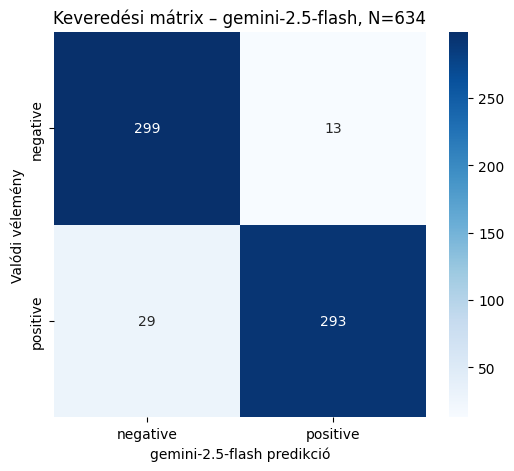

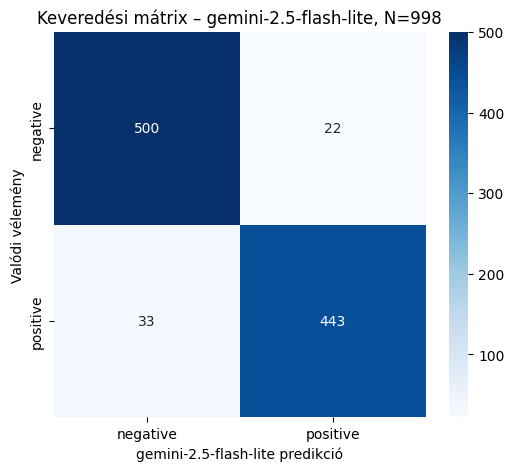

In [ ]:
# ============================================================
# 14. Keveredési mátrix ábrázolása
# ============================================================

for model_name in MODEL_NAMES:
    pred_col = f"gemini_prediction_{model_name.replace('.', '_').replace('-', '_')}"
    eval_df = sample_df.dropna(subset=[pred_col]).copy()

    y_true = eval_df["sentiment"]
    y_pred = eval_df[pred_col]

    cm = confusion_matrix(y_true, y_pred, labels=["negative", "positive"])

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["negative", "positive"],
        yticklabels=["negative", "positive"]
    )
    plt.title(f"Keveredési mátrix – {model_name}, N={len(eval_df)}")
    plt.xlabel(f"{model_name} predikció")
    plt.ylabel("Valódi vélemény")
    plt.show()



## 15. Hibás besorolások listázása

Ez a cella segít a kvalitatív hibaanalízisben.
Megnézheted, mely review-kat sorolta tévesen pozitívnak vagy negatívnak a Gemini.

A kétmodell-es változatban külön megjelenítjük a **Gemini 2.5 Flash** és a
**Gemini 2.5 Flash-Lite** hibás besorolásait, hogy kvalitatív szinten is
összehasonlítható legyen a működésük.



In [ ]:
# ============================================================
# 15. Hibás besorolások listázása
# ============================================================

for model_name in MODEL_NAMES:
    pred_col = f"gemini_prediction_{model_name.replace('.', '_').replace('-', '_')}"
    eval_df = sample_df.dropna(subset=[pred_col]).copy()
    errors_df = eval_df[eval_df["sentiment"] != eval_df[pred_col]].copy()

    print("=" * 80)
    print(f"Hibás besorolások – {model_name}")
    print("Hibás besorolások száma:", len(errors_df))

    display(errors_df[["review", "sentiment", pred_col]].head(10))



Hibás besorolások – gemini-2.5-flash
Hibás besorolások száma: 42


,review,sentiment,gemini_prediction_gemini_2_5_flash
17,I was first introduced to John Waters films by...,positive,negative
29,Three kids are born during a solar eclipse and...,positive,negative
64,"""The Garden of Allah"" was one of the first fea...",positive,negative
94,"This movie is sort of similar to ""Better Off D...",positive,negative
145,"I liked the quiet noir of the first part, the ...",positive,negative
148,It's telling that as of the entry of this comm...,negative,positive
153,"This was/is an incredible movie, with incredib...",positive,negative
169,"A 'Wes Craven presents' movie from 1995, direc...",negative,positive
196,The Ali G character works brilliantly within t...,positive,negative
244,There is a DVD published in the UK in 2002 Cod...,negative,positive


Hibás besorolások – gemini-2.5-flash-lite
Hibás besorolások száma: 55


,review,sentiment,gemini_prediction_gemini_2_5_flash_lite
17,I was first introduced to John Waters films by...,positive,negative
20,"The production quality, cast, premise, authent...",positive,negative
21,I've never really been sure whether I liked th...,positive,negative
34,Definitely one of the lesser of the Astaire/Ro...,positive,negative
62,Hammerhead is a combination between the mad sc...,negative,positive
69,"OK, imagine that every state in the US, nay, e...",negative,positive
94,"This movie is sort of similar to ""Better Off D...",positive,negative
145,"I liked the quiet noir of the first part, the ...",positive,negative
159,... so I thought I'd throw in a few words abou...,negative,positive
169,"A 'Wes Craven presents' movie from 1995, direc...",negative,positive


## 16. Rövid kutatásmódszertani értelmezés

Ez a notebook egy **LLM-alapú sentiment osztályozási pilot** megoldást valósít meg.
A mintaalapú megközelítés előnye, hogy:

- gyorsan kipróbálható ugyanaz az elemzési pipeline több modellen,
- ellenőrizhető, hogy a különböző Gemini-modellek mennyire stabilan reprodukálják az IMDb-címkéket,
- a kvantitatív mutatók mellett kvalitatív hibaanalízis is végezhető,
- ugyanazon mintán közvetlenül összehasonlítható a **Gemini 2.5 Flash** és a **Gemini 2.5 Flash-Lite** teljesítménye.

Ez a megoldás különösen hasznos előkészítő, pilot vagy benchmark-jellegű kutatásokban,
ahol a cél nemcsak az osztályozás, hanem a modellek viselkedésének összevetése is.



In [ ]:
# ============================================================
# 16/A. Megjegyzés a további bővítéshez
# ============================================================

print("A Gemini Flash vs Flash-Lite összehasonlító notebook előkészítése elkészült.")



A Gemini Flash vs Flash-Lite összehasonlító notebook előkészítése elkészült.
